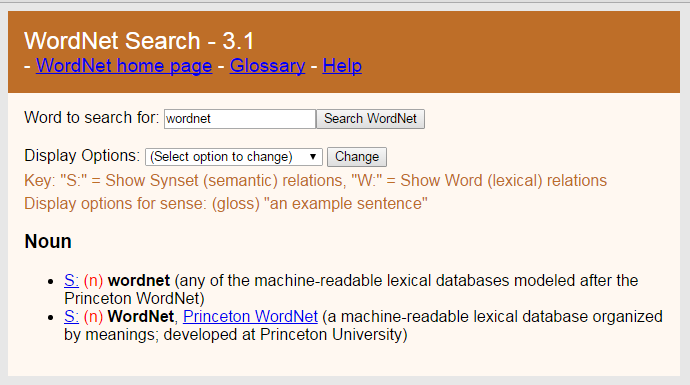

## https://wordnet.princeton.edu/
#### George A. Miller (1995). WordNet: A Lexical Database for English. Communications of the ACM Vol. 38, No. 11: 39-41.
#### Christiane Fellbaum (1998, ed.) WordNet: An Electronic Lexical Database. Cambridge, MA: MIT Press.

In [1]:
# Instalar NLTK
# python > 3.8
# $pip install nltk
# python -m nltk.downloader all

In [1]:
import nltk, re, os
from nltk.corpus import wordnet as wn
from notebook import *

In [ ]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /home/matias/nltk_data...


True

# Taxonomía de Wordnet
## WordNet es una gran base de datos lexica en Inglés. Los sustantivos, verbos, adjetivos y adverbios se agrupan en conjuntos de sinónimos (synsets), cada uno expresando un concepto distinto. Los sinsets están interconectados por medio de relaciones conceptuales-semánticas y léxicas.
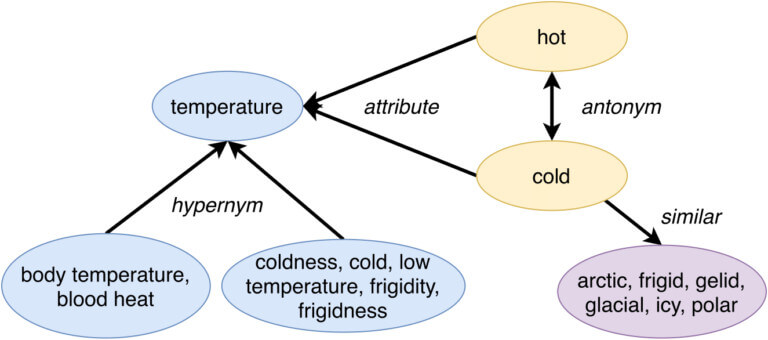

# Los significados de las palabras están representados por medio de "synsets"
## Para acceder a los synsets, se requiere la palabra y su tipo
## Tipos de palabras: NOUN, ADV, VERB, ADJ
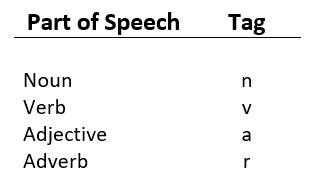

In [2]:
# Tipos de palabras
syn = wn.synsets('dog')[0]
print ("Syn PoS : ", syn.pos())
syn = wn.synsets('eat')[0]
print ("Syn PoS : ", syn.pos())
syn = wn.synsets('beautiful')[0]
print ("Syn PoS : ", syn.pos())
syn = wn.synsets('quickly')[0]
print ("Syn PoS : ", syn.pos())


Syn PoS :  n
Syn PoS :  v
Syn PoS :  a
Syn PoS :  r


In [12]:
syn = wn.synsets('dog')[0]

In [13]:
type(syn)

nltk.corpus.reader.wordnet.Synset

In [14]:
syn

Synset('dog.n.01')

In [16]:
dir(syn)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_all_hypernyms',
 '_definition',
 '_doc',
 '_examples',
 '_frame_ids',
 '_hypernyms',
 '_instance_hypernyms',
 '_iter_hypernym_lists',
 '_lemma_names',
 '_lemma_pointers',
 '_lemmas',
 '_lexname',
 '_max_depth',
 '_min_depth',
 '_name',
 '_needs_root',
 '_offset',
 '_pointers',
 '_pos',
 '_related',
 '_shortest_hypernym_paths',
 '_wordnet_corpus_reader',
 'acyclic_tree',
 'also_sees',
 'attributes',
 'causes',
 'closure',
 'common_hypernyms',
 'definition',
 'entailments',
 'examples',
 'frame_ids',
 'hypernym_distances',
 'hypernym_paths',
 'hypernyms',
 'hyponyms',
 'in_region_domains',
 'in_topic_domains

In [24]:
help(syn.tree)

Help on method tree in module nltk.corpus.reader.wordnet:

tree(rel, depth=-1, cut_mark=None) method of nltk.corpus.reader.wordnet.Synset instance
    Return the full relation tree, including self,
    discarding cycles:
    
    >>> from nltk.corpus import wordnet as wn
    >>> from pprint import pprint
    >>> computer = wn.synset('computer.n.01')
    >>> topic = lambda s:sorted(s.topic_domains())
    >>> pprint(computer.tree(topic))
    [Synset('computer.n.01'), [Synset('computer_science.n.01')]]
    
    
    
    But keep duplicate branches (from 'animal.n.01' to 'entity.n.01'):
    
    >>> dog = wn.synset('dog.n.01')
    >>> hyp = lambda s:sorted(s.hypernyms())
    >>> pprint(dog.tree(hyp))
    [Synset('dog.n.01'),
     [Synset('canine.n.02'),
      [Synset('carnivore.n.01'),
       [Synset('placental.n.01'),
        [Synset('mammal.n.01'),
         [Synset('vertebrate.n.01'),
          [Synset('chordate.n.01'),
           [Synset('animal.n.01'),
            [Synset('organism.n.

In [25]:
%psource wn

class WordNetCorpusReader(CorpusReader):
    """
    A corpus reader used to access wordnet or its variants.
    """

    _ENCODING = "utf8"

    # { Part-of-speech constants
    ADJ, ADJ_SAT, ADV, NOUN, VERB = "a", "s", "r", "n", "v"
    # }

    # { Filename constants
    _FILEMAP = {ADJ: "adj", ADV: "adv", NOUN: "noun", VERB: "verb"}
    # }

    # { Part of speech constants
    _pos_numbers = {NOUN: 1, VERB: 2, ADJ: 3, ADV: 4, ADJ_SAT: 5}
    _pos_names = dict(tup[::-1] for tup in _pos_numbers.items())
    # }

    #: A list of file identifiers for all the fileids used by this
    #: corpus reader.
    _FILES = (
        "cntlist.rev",
        "lexnames",
        "index.sense",
        "index.adj",
        "index.adv",
        "index.noun",
        "index.verb",
        "data.adj",
        "data.adv",
        "data.noun",
        "data.verb",
        "adj.exc",
        "adv.exc",
        "noun.exc",
        "verb.exc",
    )

    def __init__(self, root, omw_reader):
        """
  

In [25]:
#Obtener los synsets por palabra y tipo de palabra
word1=wn.synsets('person', pos=wn.NOUN)
word2=wn.synsets('man', pos=wn.NOUN)

In [26]:
word1

[Synset('person.n.01'), Synset('person.n.02'), Synset('person.n.03')]

In [6]:
# imprimir los synsets de la palabra y a su definición de cada uno
# se cuentan con i synsets para cada significado posible que tenga
for i in range(len(word1)):    
    print("Synset: "+str(word1[i]))
    print("Lemmas: "+str(word1[i].lemma_names()))
    print("Definition: "+str(word1[i].definition()))
    print("Examples:"+str(word1[i].examples())+"\n")

Synset: Synset('person.n.01')
Lemmas: ['person', 'individual', 'someone', 'somebody', 'mortal', 'soul']
Definition: a human being
Examples:['there was too much for one person to do']

Synset: Synset('person.n.02')
Lemmas: ['person']
Definition: a human body (usually including the clothing)
Examples:['a weapon was hidden on his person']

Synset: Synset('person.n.03')
Lemmas: ['person']
Definition: a grammatical category used in the classification of pronouns, possessive determiners, and verb forms according to whether they indicate the speaker, the addressee, or a third party
Examples:['stop talking about yourself in the third person']



In [6]:
# imprimir los synsets de la palabra y a su definición de cada uno
# se cuentan con i synsets para cada significado posible que tenga
for i in range(len(word2)):    
    print("Synset: "+str(word2[i]))
    print("Lemmas: "+str(word2[i].lemma_names()))
    print("Definition: "+str(word2[i].definition()))
    print("Examples:"+str(word2[i].examples())+"\n")

Synset: Synset('man.n.01')
Lemmas: ['man', 'adult_male']
Definition: an adult person who is male (as opposed to a woman)
Examples:['there were two women and six men on the bus']

Synset: Synset('serviceman.n.01')
Lemmas: ['serviceman', 'military_man', 'man', 'military_personnel']
Definition: someone who serves in the armed forces; a member of a military force
Examples:['two men stood sentry duty']

Synset: Synset('man.n.03')
Lemmas: ['man']
Definition: the generic use of the word to refer to any human being
Examples:['it was every man for himself']

Synset: Synset('homo.n.02')
Lemmas: ['homo', 'man', 'human_being', 'human']
Definition: any living or extinct member of the family Hominidae characterized by superior intelligence, articulate speech, and erect carriage
Examples:[]

Synset: Synset('man.n.05')
Lemmas: ['man']
Definition: a male subordinate
Examples:['the chief stationed two men outside the building', 'he awaited word from his man in Havana']

Synset: Synset('man.n.06')
Lemmas

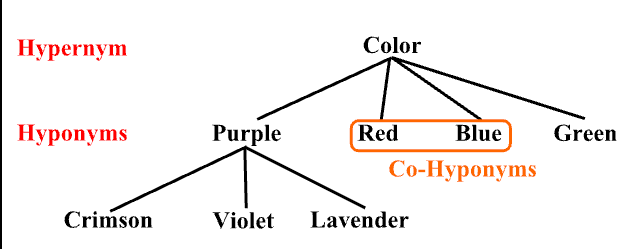

# Hyperonimos de un synset

In [7]:
# Recuperar los hiperonimos de una synset
# Utilizando el synset: Synset('person.n.01'), accedemos a este al elegir el primero de los synsets de la lista obtenida anteriormente
for H in word1[0].hypernyms():
    print(H)

Synset('causal_agent.n.01')
Synset('organism.n.01')


In [8]:
# Recuperar la lista de hiperonimos hasta el nodo raíz de Wordnet
for H in word1[0].hypernym_paths():
    print("Lista de Hiperonimos:"+str(H)) #Se lee de derecha a izquierda, todos los caminos concluyen en el Synset Entidad

Lista de Hiperonimos:[Synset('entity.n.01'), Synset('physical_entity.n.01'), Synset('causal_agent.n.01'), Synset('person.n.01')]
Lista de Hiperonimos:[Synset('entity.n.01'), Synset('physical_entity.n.01'), Synset('object.n.01'), Synset('whole.n.02'), Synset('living_thing.n.01'), Synset('organism.n.01'), Synset('person.n.01')]


# Wordnet provee de funciones que nos permiten identificar que información y cómo están relacionados los synsets

In [9]:
#Obtener los synsets por palabra y tipo de palabra
word1=wn.synsets('cat', pos=wn.NOUN)
word2=wn.synsets('dog', pos=wn.NOUN)

In [10]:
# Recuperar la lista de hiperónimos hasta el nodo raíz de Wordnet
for H in word1[0].hypernym_paths():
    print("Lista de Hiperonimos:"+str(H),len(H)) #Se lee de derecha a izquierda, todos los caminos concluyen en el Synset Entidad

Lista de Hiperonimos:[Synset('entity.n.01'), Synset('physical_entity.n.01'), Synset('object.n.01'), Synset('whole.n.02'), Synset('living_thing.n.01'), Synset('organism.n.01'), Synset('animal.n.01'), Synset('chordate.n.01'), Synset('vertebrate.n.01'), Synset('mammal.n.01'), Synset('placental.n.01'), Synset('carnivore.n.01'), Synset('feline.n.01'), Synset('cat.n.01')] 14


In [11]:
# Podemos obtener el número de Synsets de sus hiperónimos que conforman el camino más corto hasta la raíz.
word2[0].min_depth()

8

In [12]:
# Podemos obtener el número de Synsets de sus hiperónimos que conforman el camino más largo hasta la raíz.
word2[0].max_depth()

13

In [13]:
# Obtener el camino más corto entre dos synsets
word1[0].shortest_path_distance(word2[0])

4

# Hiperonym - Hyponyms
## Palabras cuyo significado engloba el de otras. Y viceversa.

In [14]:
# Recuperar la lista de hiperónimos hasta el nodo raíz de Wordnet
for H in word2[0].hypernym_paths():
    print("Lista de Hiperonimos:"+str(H),len(H)) #Se lee de derecha a izquierda, todos los caminos concluyen en el Synset Entidad

Lista de Hiperonimos:[Synset('entity.n.01'), Synset('physical_entity.n.01'), Synset('object.n.01'), Synset('whole.n.02'), Synset('living_thing.n.01'), Synset('organism.n.01'), Synset('animal.n.01'), Synset('chordate.n.01'), Synset('vertebrate.n.01'), Synset('mammal.n.01'), Synset('placental.n.01'), Synset('carnivore.n.01'), Synset('canine.n.02'), Synset('dog.n.01')] 14
Lista de Hiperonimos:[Synset('entity.n.01'), Synset('physical_entity.n.01'), Synset('object.n.01'), Synset('whole.n.02'), Synset('living_thing.n.01'), Synset('organism.n.01'), Synset('animal.n.01'), Synset('domestic_animal.n.01'), Synset('dog.n.01')] 9


In [15]:
#Podemos obtener los hiperónimos mque comparten dos synsets
word1[0].common_hypernyms(word2[0])

[Synset('animal.n.01'),
 Synset('living_thing.n.01'),
 Synset('physical_entity.n.01'),
 Synset('placental.n.01'),
 Synset('organism.n.01'),
 Synset('whole.n.02'),
 Synset('object.n.01'),
 Synset('mammal.n.01'),
 Synset('carnivore.n.01'),
 Synset('entity.n.01'),
 Synset('vertebrate.n.01'),
 Synset('chordate.n.01')]

In [16]:
#Podemos obtener el hiperónimo más cercano que comparten dos synsets
word1[0].lowest_common_hypernyms(word2[0])

[Synset('carnivore.n.01')]

In [17]:
# Obtener las distancias de cada hiperónimo con respecto al synset
word2[0].hypernym_distances()

{(Synset('animal.n.01'), 2),
 (Synset('animal.n.01'), 7),
 (Synset('canine.n.02'), 1),
 (Synset('carnivore.n.01'), 2),
 (Synset('chordate.n.01'), 6),
 (Synset('dog.n.01'), 0),
 (Synset('domestic_animal.n.01'), 1),
 (Synset('entity.n.01'), 8),
 (Synset('entity.n.01'), 13),
 (Synset('living_thing.n.01'), 4),
 (Synset('living_thing.n.01'), 9),
 (Synset('mammal.n.01'), 4),
 (Synset('object.n.01'), 6),
 (Synset('object.n.01'), 11),
 (Synset('organism.n.01'), 3),
 (Synset('organism.n.01'), 8),
 (Synset('physical_entity.n.01'), 7),
 (Synset('physical_entity.n.01'), 12),
 (Synset('placental.n.01'), 3),
 (Synset('vertebrate.n.01'), 5),
 (Synset('whole.n.02'), 5),
 (Synset('whole.n.02'), 10)}

In [18]:
# Podemos buscar el árbol entre los synsets
hand = wn.synset('hand.n.01')
head = wn.synset('head.n.01')

In [19]:
hand.tree(head)

[Synset('hand.n.01')]

In [20]:
# Recuperar la lista de hiperónimos hasta el nodo raíz de Wordnet
for h in word2[0].hyponyms():
    print("Hipónimos: "+str(h)) #Se lee de derecha a izquierda, todos los caminos concluyen en el Synset Entidad

Hipónimos: Synset('basenji.n.01')
Hipónimos: Synset('corgi.n.01')
Hipónimos: Synset('cur.n.01')
Hipónimos: Synset('dalmatian.n.02')
Hipónimos: Synset('great_pyrenees.n.01')
Hipónimos: Synset('griffon.n.02')
Hipónimos: Synset('hunting_dog.n.01')
Hipónimos: Synset('lapdog.n.01')
Hipónimos: Synset('leonberg.n.01')
Hipónimos: Synset('mexican_hairless.n.01')
Hipónimos: Synset('newfoundland.n.01')
Hipónimos: Synset('pooch.n.01')
Hipónimos: Synset('poodle.n.01')
Hipónimos: Synset('pug.n.01')
Hipónimos: Synset('puppy.n.01')
Hipónimos: Synset('spitz.n.01')
Hipónimos: Synset('toy_dog.n.01')
Hipónimos: Synset('working_dog.n.01')


# Meronyms - Holonyms
## Relación idiomática que existe entre dos palabras cuando una palabra es parte o un miembro de la otra.

In [21]:
# Elección del synset
hand = wn.synset('hand.n.01')

In [22]:
hand.part_meronyms()

[Synset('ball.n.10'),
 Synset('digital_arteries.n.01'),
 Synset('finger.n.01'),
 Synset('intercapitular_vein.n.01'),
 Synset('metacarpal_artery.n.01'),
 Synset('metacarpal_vein.n.01'),
 Synset('metacarpus.n.01'),
 Synset('palm.n.01')]

In [23]:
hand.part_holonyms()

[Synset('arm.n.01'), Synset('homo.n.02')]

# Synonym - Antonyms

In [24]:
word1="man"

In [25]:
# obtener los sinonimos y antonimos de una palabra
synonyms=[]
antonyms=[]
for syn in wn.synsets(word1):
    for l in syn.lemmas():
        synonyms.append(l.name())
        if l.antonyms():
            antonyms.append(l.antonyms()[0].name())

In [26]:
synonyms

['man',
 'adult_male',
 'serviceman',
 'military_man',
 'man',
 'military_personnel',
 'man',
 'homo',
 'man',
 'human_being',
 'human',
 'man',
 'man',
 'valet',
 'valet_de_chambre',
 'gentleman',
 "gentleman's_gentleman",
 'man',
 'man',
 'Man',
 'Isle_of_Man',
 'man',
 'piece',
 'world',
 'human_race',
 'humanity',
 'humankind',
 'human_beings',
 'humans',
 'mankind',
 'man',
 'man',
 'man']

In [27]:
antonyms

['woman', 'civilian', 'woman']

# Words Similarity
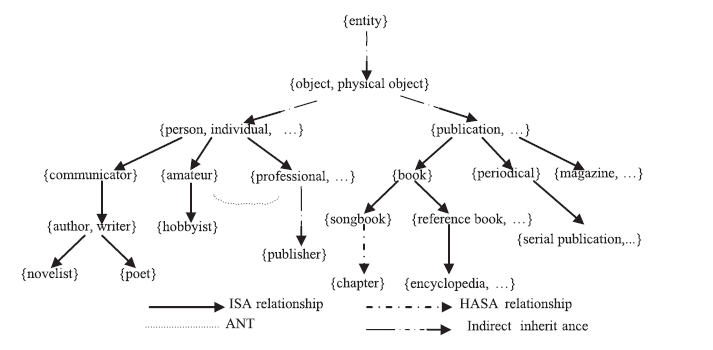

# WuPalmer – WordNet Similarity
## Calcula la relación considerando las profundidades de los dos synsets en las taxonomías de WordNet, junto con la profundidad del LCS (Least Common Subsumer). Este valor se encuentra entre 0 y 1.
## Medida basada en la similitud de las palabras y Synsets en relación con sus hipérónimos.
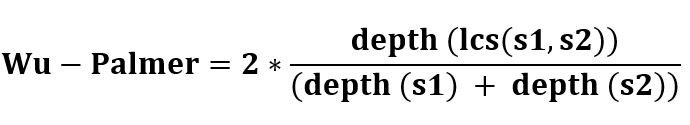

In [29]:
#Obtener los synsets por palabra y tipo de palabra
word1=wn.synsets('cat', pos=wn.NOUN)
word2=wn.synsets('dog', pos=wn.NOUN)

In [30]:
# cat y dog
word1[0].wup_similarity(word2[0])

0.8571428571428571

# Path similarity

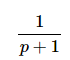
## donde p es el camino más corte entre palabras (shortest_path_distance)
## Es una medida de similitud que encuentra la relación de la longitud de la ruta más corta entre dos synsets.

In [31]:
# cat y dog
word1[0].path_similarity(word2[0])

0.2

# Leacock Chordorow (LCH)
## Versión extendida de la similitud basada en Path, ya que incorpora la profundidad de la taxonomía.
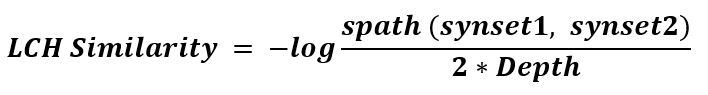

In [32]:
word1[0].lch_similarity(word2[0])  

2.0281482472922856

### Documentación adicional: https://wn.readthedocs.io/en/latest/api/wn.similarity.html

# Similarity VERB

In [33]:
#Obtener los synsets por palabra y tipo de palabra
word1=wn.synsets('sit', pos=wn.VERB)
word2=wn.synsets('stay', pos=wn.VERB)

In [34]:
print(word1[0],word1[0].definition())
print(word2[0],word2[0].definition())

Synset('sit.v.01') be seated
Synset('stay.v.01') stay the same; remain in a certain state


In [35]:
print("WUP:",word1[0].wup_similarity(word2[0]))
print("Path:",word1[0].path_similarity(word2[0]))
print("LCH:",word1[0].lch_similarity(word2[0]))

WUP: 0.4
Path: 0.25
LCH: 1.8718021769015913


# Similarity ADJ

In [36]:
#Obtener los synsets por palabra y tipo de palabra
word1=wn.synsets('intelligent', pos=wn.ADJ)
word2=wn.synsets('smart', pos=wn.ADJ)

In [37]:
print(word1[0],word1[0].definition())
print(word2[0],word2[0].definition())

Synset('intelligent.a.01') having the capacity for thought and reason especially to a high degree
Synset('smart.a.01') showing mental alertness and calculation and resourcefulness


In [38]:
print("WUP:",word1[0].wup_similarity(word2[0]))
print("Path:",word1[0].path_similarity(word2[0]))
print("LCH:",word1[0].lch_similarity(word2[0]))

WUP: 0.5
Path: 0.3333333333333333
LCH: -0.4054651081081644


# Similarity NOUN

In [39]:
#Obtener los synsets por palabra y tipo de palabra
word1=wn.synsets('man', pos=wn.NOUN)
word2=wn.synsets('person', pos=wn.NOUN)

In [40]:
# Nombre del synset y la definición
print(word1[0],word1[0].definition())
print(word2[0],word2[0].definition())

Synset('man.n.01') an adult person who is male (as opposed to a woman)
Synset('person.n.01') a human being


In [41]:
print("WUP:",word1[0].wup_similarity(word2[0]))
print("Path:",word1[0].path_similarity(word2[0]))
print("LCH:",word1[0].lch_similarity(word2[0]))

WUP: 0.75
Path: 0.3333333333333333
LCH: 2.538973871058276


# Similarity ADV

In [42]:
#Obtener los synsets por palabra y tipo de palabra
word1=wn.synsets('above', pos=wn.ADV)
word2=wn.synsets('around', pos=wn.ADV)

In [43]:
# Nombre del synset y la definición
print(word1[0],word1[0].definition())
print(word2[0],word2[0].definition())

Synset('above.r.01') at an earlier place
Synset('about.r.03') in the area or vicinity


In [44]:
print("WUP:",word1[0].wup_similarity(word2[0]))
print("Path:",word1[0].path_similarity(word2[0]))
print("LCH:",word1[0].lch_similarity(word2[0]))

WUP: 0.5
Path: 0.3333333333333333
LCH: -0.4054651081081644


# Part of speech tagged

In [45]:
from nltk.corpus import wordnet
nltk.download('universal_tagset')

def get_wordnet_pos(word):
    if word.startswith('ADJ'):
        return wordnet.ADJ
    elif word.startswith('V'):
        return wordnet.VERB
    elif word.startswith('N'):
        return wordnet.NOUN
    elif word.startswith('ADV'):
        return wordnet.ADV
    else:
        return wordnet.NOUN


[nltk_data] Downloading package universal_tagset to
[nltk_data]     C:\Users\Ninja\AppData\Roaming\nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


In [46]:
text = "A group of kids is playing in a yard and an old man is standing in the background"
text_token = nltk.word_tokenize(text)
text_token = nltk.pos_tag(text_token, tagset="universal")
text_token

[('A', 'DET'),
 ('group', 'NOUN'),
 ('of', 'ADP'),
 ('kids', 'NOUN'),
 ('is', 'VERB'),
 ('playing', 'VERB'),
 ('in', 'ADP'),
 ('a', 'DET'),
 ('yard', 'NOUN'),
 ('and', 'CONJ'),
 ('an', 'DET'),
 ('old', 'ADJ'),
 ('man', 'NOUN'),
 ('is', 'VERB'),
 ('standing', 'VERB'),
 ('in', 'ADP'),
 ('the', 'DET'),
 ('background', 'NOUN')]

In [47]:
# import these modules
from nltk.stem import WordNetLemmatizer
 
lemmatizer = WordNetLemmatizer()
 
lemas = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in text_token]
pos = [get_wordnet_pos(tag) for word, tag in text_token]
print(lemas)
print(pos)

['A', 'group', 'of', 'kid', 'be', 'play', 'in', 'a', 'yard', 'and', 'an', 'old', 'man', 'be', 'stand', 'in', 'the', 'background']
['n', 'n', 'n', 'n', 'v', 'v', 'n', 'n', 'n', 'n', 'n', 'a', 'n', 'v', 'v', 'n', 'n', 'n']


# Example Sentence Similarity Wordnet

# Jaro Distance
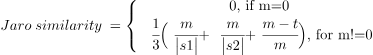
###  s1 y s2 son frases
###  m es el número de match entre palabras de la primera frase y la segunda
###  t es el número de transposiciones en el orden en que aparecen las palabras

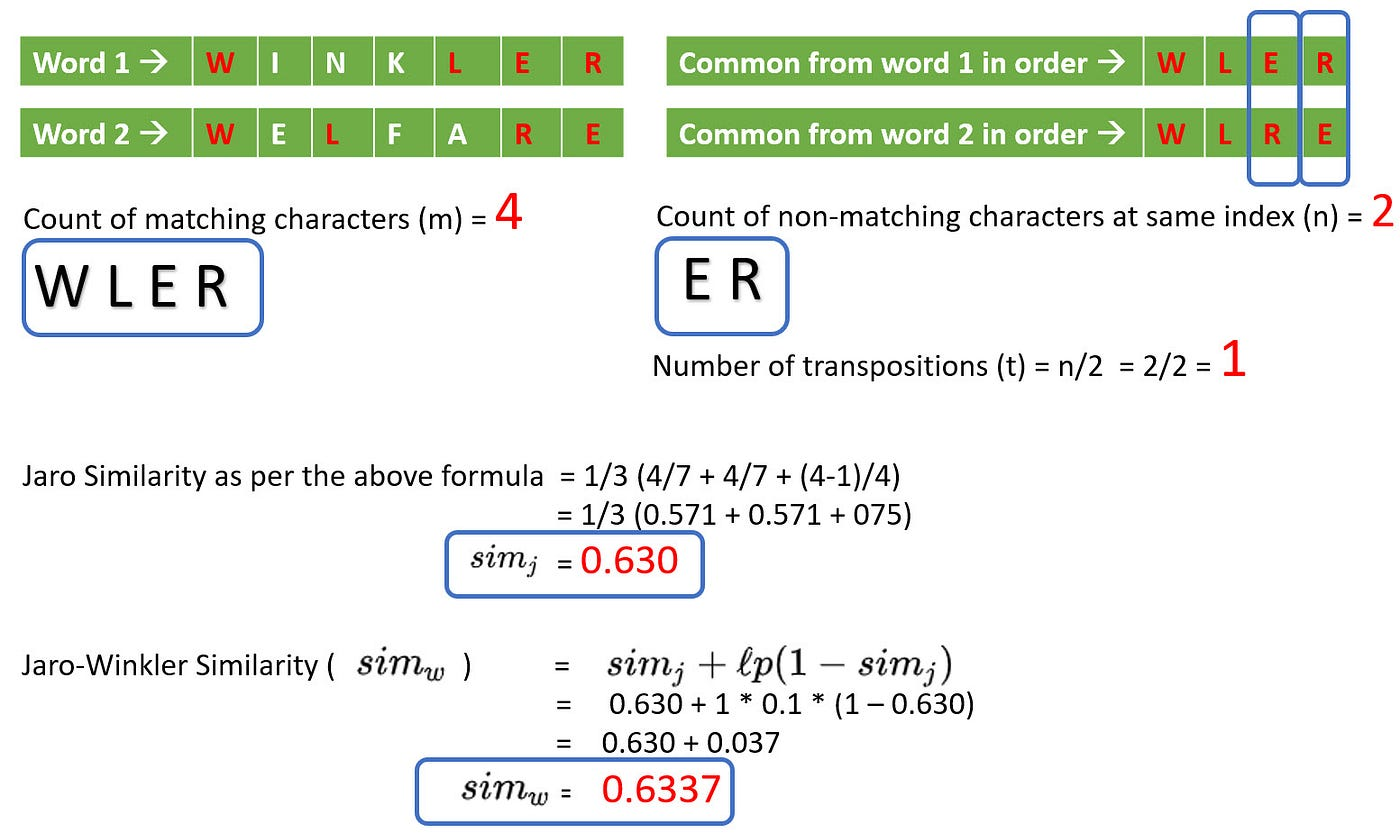

In [73]:
dicPoS={
    'n':wn.NOUN,
    'v':wn.VERB,
    'a':wn.ADJ,
    'r':wn.ADV,
}

# Esta función se modificó para poder hacer la comparación entre frases de texto tomando en cuenta la métrica path_similarity entre synsets
# se le proporciona como argumentos una lista de tokens  de cada frase así como una lista de sus respectivos PoS
def jaro_distance(s1, pos1, s2,pos2):
    bandera=True

    # Length of two sentences
    len1 = len(s1)
    len2 = len(s2)

    # If the listas de tokens are equal 
    if len1==len2:
        for i in range(len1):
            if s1[i]!=s2[i]:
                bandera=False
                break
        if (bandera):
            return 1.0
 
    if (len1 == 0 or len2 == 0) :
        return 0.0
 
    # Maximum distance upto which matching 
    # is allowed 
    max_dist = (max(len(s1), len(s2)) // 2 )-1 ; 
 
    # Count of matches 
    match = 0; 
 
    # Hash for matches 
    hash_s1 = [0] * len(s1)
    hash_s2 = [0] * len(s2)
 
    # Traverse through the first string 
    for i in range(len1):
        #Synset word1 and PoS
        w1=wn.synsets(s1[i], pos=pos1[i])
        if(len(w1)>0):
            w1=w1[0]
            # Check if there is any matches
            for j in range(max(0, i - max_dist), min(len2, i + max_dist + 1)):
                #Synset word2 and PoS
                w2=wn.synsets(s2[j], pos=pos2[j])
                if(len(w2)>0):
                    w2=w2[0]
                    # If there is a match or is contain in a bag of sinomys of tk
                    if (s1[i] == s2[j]):
                        match += 1; 
                        hash_s1[i] = 1
                        hash_s2[j] = 1
                        break
                    # compare PoS of tokens 
                    elif pos1[i]==pos2[j]:
                        # Similarity above 0.75
                        if ((w1.path_similarity(w2)>=0.75) and hash_s2[j] == 0):
                            hash_s1[i] = 1
                            hash_s2[j] = 1
                            match += 1; 
                            break
    # If there is no match 
    if (match == 0) :
        return 0.0; 
 
    # Number of transpositions 
    t = 0; 
 
    point = 0; 
 
    # Count number of occurrences 
    # where two characters match but 
    # there is a third matched character 
    # in between the indices 
    for i in range(len1) : 
        if (hash_s1[i]) :
            # Find the next matched character 
            # in second string 
            while (hash_s2[point] == 0) :
                point += 1; 
 
            if (s1[i] != s2[point]) :
                point += 1
                t += 1
            else :
                point += 1    
    t /= 2; 

    #Return the Jaro Similarity 
    return (( match / len2  + match / len1 + (match - t) / match ) / 3.0); 

In [74]:
# Frases a procesar
text1="A man and a dog are walking together through wooded areas"
text2="A man and an animal are walking together through woods"

In [75]:
# Procedimiento de tokenización 
text1_token = nltk.word_tokenize(text1)
text1_token = nltk.pos_tag(text1_token, tagset="universal")
text2_token = nltk.word_tokenize(text2)
text2_token = nltk.pos_tag(text2_token, tagset="universal")

In [76]:
# Obtener los lemas
lemmatizer = WordNetLemmatizer()
 
lemas1 = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in text1_token]
pos1 = [get_wordnet_pos(tag) for word, tag in text1_token]

lemas2 = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in text2_token]
pos2 = [get_wordnet_pos(tag) for word, tag in text2_token]


In [77]:
print("Texto 1: ",text1)
print("lemmas: ",lemas1)
print("PoS: ",pos1)
print()
print("Texto 2: ",text2)
print("lemmas: ",lemas2)
print("PoS: ",pos2)

Texto 1:  A man and a dog are walking together through wooded areas
lemmas:  ['A', 'man', 'and', 'a', 'dog', 'be', 'walk', 'together', 'through', 'wooded', 'area']
PoS:  ['n', 'n', 'n', 'n', 'n', 'v', 'v', 'r', 'n', 'v', 'n']

Texto 2:  A man and an animal are walking together through woods
lemmas:  ['A', 'man', 'and', 'an', 'animal', 'be', 'walk', 'together', 'through', 'wood']
PoS:  ['n', 'n', 'n', 'n', 'n', 'v', 'v', 'r', 'n', 'n']


In [78]:
print("Similitud Jaro con Wordnet: ",jaro_distance(lemas1, pos1, lemas2,pos2))

Similitud Jaro con Wordnet:  0.6515151515151515


### Respuesta de Gemini sobre cómo recorrer tosas las aristas del grafo

Para recorrer todas las aristas (relaciones) del grafo de WordNet utilizando la clase WordNetCorpusReader de NLTK, necesitas iterar por cada uno de los nodos (Synsets) y extraer los punteros hacia otros synsets que actúan como aristas (hiperónimos, hipónimos, holónimos, etc.).

Dado que estás trabajando con la estructura interna de la librería, la forma más eficiente de hacerlo sin cargar todo el diccionario en memoria es utilizando un generador con el método all_synsets().

Aquí tienes la solución implementada a través de un script limpio y estructurado:

Solución para recorrer todas las aristas
Puedes crear una función que recorra todos los synsets de todas las categorías gramaticales (NOUN, VERB, ADJ, ADV) y extraiga los objetivos de cada puntero:

In [ ]:
def recorrer_todas_las_aristas(wn_reader):
    """
    Itera sobre todos los synsets y genera las aristas del grafo.
    Cada arista se devuelve como una tupla: (nodo_origen, tipo_relacion, nodo_destino)
    """
    # Lista de categorías gramaticales soportadas en WordNet
    categorias_pos = [wn_reader.NOUN, wn_reader.VERB, wn_reader.ADJ, wn_reader.ADV]
    
    for pos in categorias_pos:
        # all_synsets devuelve un iterador sobre los archivos de datos
        for synset_origen in wn_reader.all_synsets(pos=pos):
            
            # synset_origen._pointers contiene un diccionario: { símbolo_relación: {(pos, offset), ...} }
            for simbolo, objetivos in synset_origen._pointers.items():
                for pos_destino, offset_destino in objetivos:
                    
                    # Reconstruimos el nodo destino usando el offset de bytes
                    synset_destino = wn_reader.synset_from_pos_and_offset(pos_destino, offset_destino)
                    
                    if synset_destino:
                        # Retornamos la arista de forma perezosa (yield) para ahorrar memoria
                        yield (synset_origen, simbolo, synset_destino)

### ¿Cómo usarlo con tu objeto?
Asumiendo que ya tienes instanciada tu clase WordNetCorpusReader (por ejemplo, a través del objeto wn estándar de NLTK o tu propia instancia), puedes procesar las aristas de la siguiente manera:

In [ ]:
# Ejemplo de uso:
# reader = WordNetCorpusReader(root_path, omw_reader)

contador_aristas = 0

print("Iniciando recorrido del grafo...")
for origen, relacion, destino in recorrer_todas_las_aristas(reader):
    # Aquí puedes procesar la arista. Ejemplo con los primeros 5 resultados:
    if contador_aristas < 5:
        print(f"Arista: {origen.name()} --({relacion})--> {destino.name()}")
        
    contador_aristas += 1

print(f"\n¡Recorrido completado! Total de aristas encontradas: {contador_aristas}")

### ¿Por qué se hace así en este código?
1. all_synsets(pos): Lee línea por línea los archivos de texto planos de WordNet (data.noun, data.verb, etc.). Esto evita colapsar la memoria RAM.

2. synset_origen._pointers: Durante la lectura de la línea (en el método _synset_from_pos_and_line), NLTK almacena los punteros semánticos en este diccionario privado. El símbolo (ej. @ para hiperónimos, ~ para hipónimos) mapea directamente a las tuplas de coordenadas físicas (pos, offset).

3. synset_from_pos_and_offset: Traduce esas coordenadas directamente en el objeto Synset de destino de forma inmediata utilizando un puntero de archivo (seek).